In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Load Datasets

disease_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\Diseases_and_Symptoms_dataset.csv")

description_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\description.csv")

diet_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\diets.csv")

medication_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\medications.csv")

precaution_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\precautions.csv")

workout_df = pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\AI HealthCare\data\raw\workout.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [6]:
print("Disease Dataset      :", disease_df.shape)
print("Description Dataset  :", description_df.shape)
print("Diet Dataset         :", diet_df.shape)
print("Medication Dataset   :", medication_df.shape)
print("Precaution Dataset   :", precaution_df.shape)
print("Workout Dataset      :", workout_df.shape)

Disease Dataset      : (96088, 231)
Description Dataset  : (100, 2)
Diet Dataset         : (100, 2)
Medication Dataset   : (100, 2)
Precaution Dataset   : (100, 5)
Workout Dataset      : (100, 2)


In [7]:
# ==========================================
# Display First Five Records
# ==========================================

disease_df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# ==========================================
# Dataset Information
# ==========================================

disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96088 entries, 0 to 96087
Columns: 231 entries, diseases to low urine output
dtypes: int64(230), object(1)
memory usage: 169.3+ MB


In [9]:
# ==========================================
# Data Types
# ==========================================

disease_df.dtypes.value_counts()

int64     230
object      1
Name: count, dtype: int64

## Observation

- The dataset contains **96,088 patient records**.
- There are **230 binary symptom features**.
- The target variable is **Disease**.
- Symptom features are stored as integer values (0 or 1).
- The target variable is stored as text (object datatype).

## Conclusion

The dataset structure is suitable for a supervised multi-class classification problem.

In [10]:
# ==========================================
# Missing Values
# ==========================================

missing_values = disease_df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


In [11]:
# ==========================================
# Duplicate Records
# ==========================================

duplicate_rows = disease_df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [12]:
# ==========================================
# Unique Disease Classes
# ==========================================

num_diseases = disease_df["diseases"].nunique()

print("Number of Diseases:", num_diseases)

Number of Diseases: 100


In [13]:
# ==========================================
# Display Disease Names
# ==========================================

disease_df["diseases"].unique()

array(['panic disorder', 'vaginitis', 'problem during pregnancy',
       'acute pancreatitis', 'asthma', 'infectious gastroenteritis',
       'acute sinusitis', 'cornea infection', 'marijuana abuse',
       'bursitis', 'actinic keratosis',
       'chronic obstructive pulmonary disease (copd)', 'spondylosis',
       'injury to the arm', 'complex regional pain syndrome',
       'injury to the trunk', 'vulvodynia', 'concussion', 'hypoglycemia',
       'hiatal hernia', 'allergy', 'acute bronchospasm',
       'degenerative disc disease', 'pain after an operation',
       'injury to the leg', 'gout', 'otitis media', 'acute kidney injury',
       'threatened pregnancy', 'gum disease',
       'gastrointestinal hemorrhage', 'anxiety',
       'conjunctivitis due to allergy', 'drug reaction',
       'macular degeneration', 'pneumonia', 'vaginal cyst',
       'carpal tunnel syndrome', 'nose disorder', 'dental caries',
       'hypertensive heart disease', 'seasonal allergies (hay fever)',
       'f

In [14]:
# ==========================================
# Disease Frequency
# ==========================================

disease_counts = disease_df["diseases"].value_counts()

disease_counts

diseases
cystitis                              1219
vulvodynia                            1218
nose disorder                         1218
complex regional pain syndrome        1217
spondylosis                           1216
                                      ... 
hypertensive heart disease             804
gum disease                            803
allergy                                803
injury to the trunk                    803
temporary or benign blood in urine     803
Name: count, Length: 100, dtype: int64

In [15]:
# ==========================================
# Dataset Statistics
# ==========================================

print(f"Most Frequent Disease : {disease_counts.idxmax()} ({disease_counts.max()} samples)")
print(f"Least Frequent Disease: {disease_counts.idxmin()} ({disease_counts.min()} samples)")
print(f"Mean Samples         : {disease_counts.mean():.2f}")
print(f"Median Samples       : {disease_counts.median()}")

Most Frequent Disease : cystitis (1219 samples)
Least Frequent Disease: gum disease (803 samples)
Mean Samples         : 960.88
Median Samples       : 824.0


## Observation

- No missing values were found in the dataset.
- No duplicate records were identified.
- The dataset contains 100 unique disease classes.
- The number of samples per disease ranges from approximately 803 to 1219.
- The distribution of disease classes is reasonably balanced.

## Conclusion

The dataset is clean and does not require missing value imputation or duplicate removal. The class distribution is sufficiently balanced for supervised multi-class classification without applying resampling techniques.

In [16]:
# ==========================================
# Configuration
# ==========================================

TARGET_COLUMN = "diseases"
FEATURE_COLUMNS = disease_df.columns.drop(TARGET_COLUMN)

print(f"Target Column : {TARGET_COLUMN}")
print(f"Number of Features : {len(FEATURE_COLUMNS)}")

Target Column : diseases
Number of Features : 230


# Symptom Frequency Analysis

## Objective

To analyze how frequently each symptom appears in the dataset.

## Why?

Understanding symptom frequency helps identify common, rare, and potentially uninformative features before model training.

In [17]:
# ==========================================
# Feature Columns
# ==========================================

feature_df = disease_df.drop(columns=[TARGET_COLUMN])

print(feature_df.shape)

(96088, 230)


In [18]:
# ==========================================
# Symptom Frequencies
# ==========================================

symptom_frequency = feature_df.sum().sort_values(ascending=False)

symptom_frequency.head(10)

sharp abdominal pain    15217
vomiting                14206
back pain               12628
nausea                  11942
cough                   11220
fever                   10641
sharp chest pain         9444
shortness of breath      9377
headache                 9241
nasal congestion         8775
dtype: int64

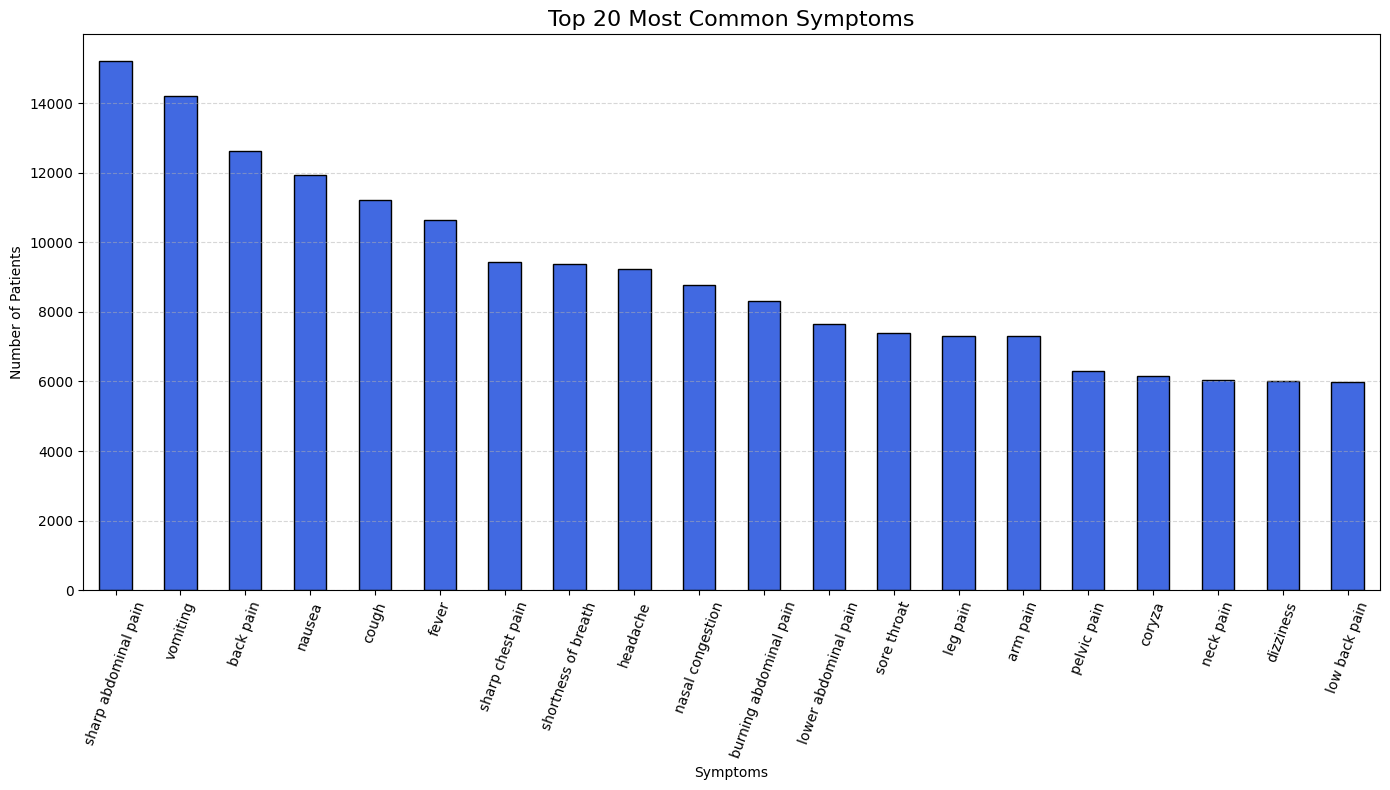

In [19]:
plt.figure(figsize=(14,8))

symptom_frequency.head(20).plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 20 Most Common Symptoms", fontsize=16)

plt.xlabel("Symptoms")

plt.ylabel("Number of Patients")

plt.xticks(rotation=70)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

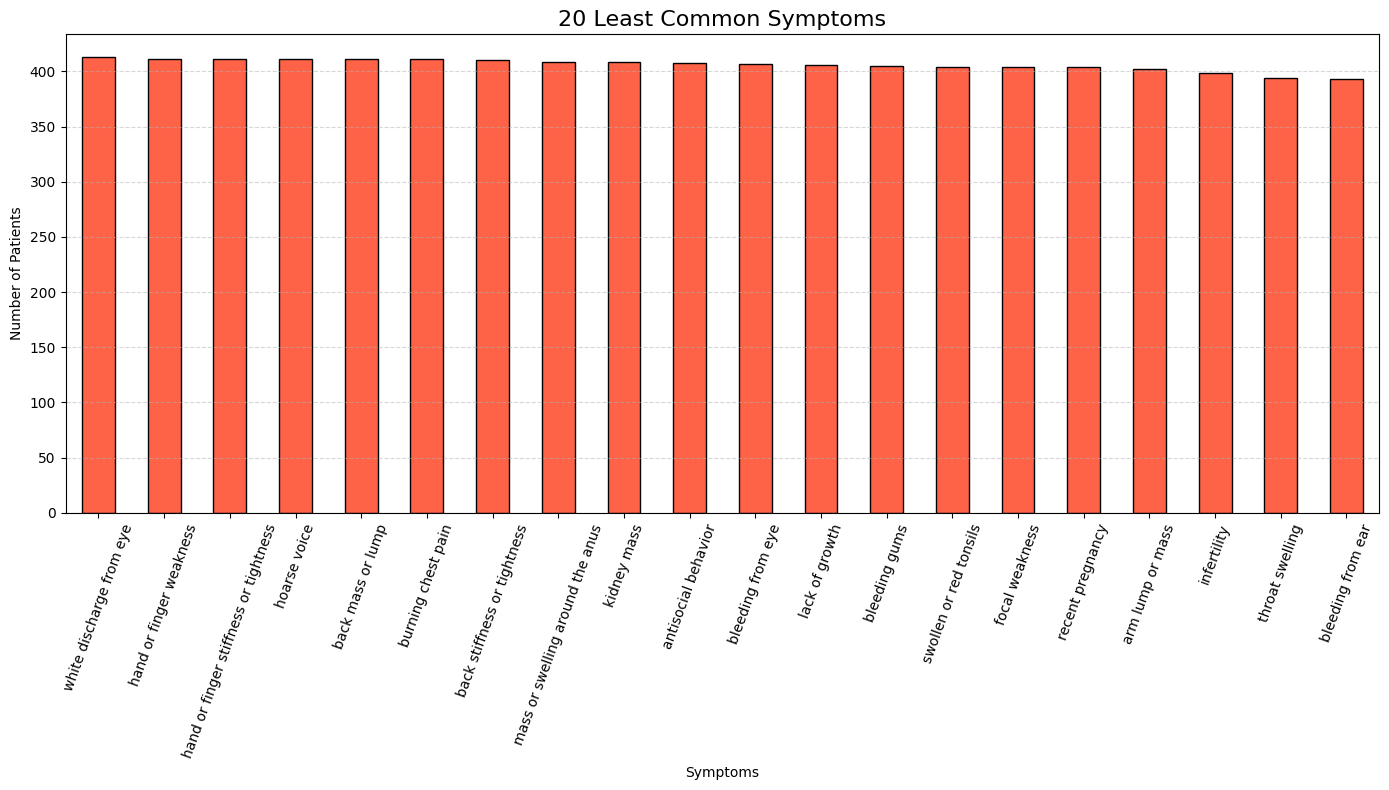

In [20]:
plt.figure(figsize=(14,8))

symptom_frequency.tail(20).plot(
    kind="bar",
    color="tomato",
    edgecolor="black"
)

plt.title("20 Least Common Symptoms", fontsize=16)

plt.xlabel("Symptoms")

plt.ylabel("Number of Patients")

plt.xticks(rotation=70)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [21]:
print("Most Common Symptom :", symptom_frequency.idxmax())
print("Frequency           :", symptom_frequency.max())

print()

print("Least Common Symptom:", symptom_frequency.idxmin())
print("Frequency           :", symptom_frequency.min())

print()

print("Average Frequency   :", round(symptom_frequency.mean(),2))

Most Common Symptom : sharp abdominal pain
Frequency           : 15217

Least Common Symptom: bleeding from ear
Frequency           : 393

Average Frequency   : 2453.45


## Observation

- Common symptoms such as sharp abdominal pain, vomiting, cough, fever, and headache appear across many patient records, indicating that they are associated with multiple diseases.
- Rare symptoms such as bleeding from the ear occur infrequently but may still provide strong discriminatory power for diagnosing specific diseases.
- The symptom frequencies show substantial variation, suggesting that some symptoms are general indicators while others are disease-specific.

## Conclusion

Feature importance should not be determined solely by symptom frequency. Rare symptoms may still contribute significantly to disease prediction and will therefore be retained for model training.

In [ ]:
# ==========================================
# Constant Features
# ==========================================

constant_features = [
    col for col in feature_df.columns
    if feature_df[col].nunique() == 1
]

print("Number of Constant Features:", len(constant_features))

constant_features

Number of Constant Features: 0


[]

## Observation

- No constant features were identified in the dataset.
- Every symptom appears in at least one patient record.
- Every symptom is absent in at least one patient record.
- Therefore, every feature contains useful variability.

## Conclusion

Since no constant features exist, no feature needs to be removed before model training.

In [24]:
# ==========================================
# Feature Variance
# ==========================================

feature_variance = feature_df.var()

feature_variance.describe()

count    230.000000
mean       0.024171
std        0.023773
min        0.004073
25%        0.006401
50%        0.016022
75%        0.031161
max        0.133287
dtype: float64

In [25]:
feature_variance.sort_values().head(10)

bleeding from ear         0.004073
throat swelling           0.004084
infertility               0.004135
arm lump or mass          0.004166
focal weakness            0.004187
swollen or red tonsils    0.004187
recent pregnancy          0.004187
bleeding gums             0.004197
lack of growth            0.004207
bleeding from eye         0.004218
dtype: float64

In [26]:
feature_variance.sort_values(ascending=False).head(10)

sharp abdominal pain    0.133287
vomiting                0.125987
back pain               0.114151
nausea                  0.108837
cough                   0.103134
fever                   0.098479
sharp chest pain        0.088626
shortness of breath     0.088065
headache                0.086924
nasal congestion        0.082984
dtype: float64

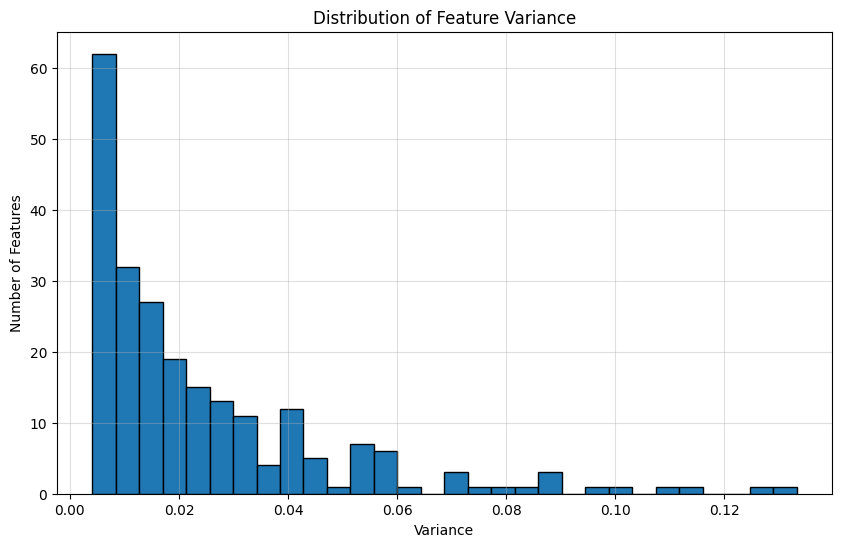

In [27]:
plt.figure(figsize=(10,6))

plt.hist(
    feature_variance,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Feature Variance")

plt.xlabel("Variance")

plt.ylabel("Number of Features")

plt.grid(alpha=0.4)

plt.show()

## Observation

- The feature variance distribution is right-skewed.
- Most symptom features have relatively low variance because many symptoms occur infrequently.
- A smaller number of symptoms exhibit higher variance, indicating they are common across multiple diseases.
- No feature has zero variance, confirming that every symptom contributes some variability to the dataset.

## Conclusion

Low-variance symptoms will not be removed at this stage because rare symptoms may still be highly informative for disease prediction. Feature importance will be evaluated later using machine learning models and explainability techniques.

In [28]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation_matrix = feature_df.corr()

print("Correlation Matrix Shape:", correlation_matrix.shape)

Correlation Matrix Shape: (230, 230)


In [29]:
# ==========================================
# Highly Correlated Feature Pairs
# ==========================================

threshold = 0.80

high_corr_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= threshold:

            high_corr_pairs.append((
                columns[i],
                columns[j],
                corr
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

print("Highly Correlated Pairs:", len(high_corr_df))

high_corr_df.head(20)

Highly Correlated Pairs: 0


,Feature 1,Feature 2,Correlation


## Observation

- Correlation analysis was performed using a threshold of 0.80.
- No highly correlated symptom pairs were identified.
- This indicates that the symptom features are not strongly redundant and capture different aspects of patient conditions.

## Conclusion

Since no highly correlated feature pairs were found, all symptom features will be retained for model training. No correlation-based feature removal is required.

In [30]:
# ==========================================
# Duplicate Feature Detection
# ==========================================

duplicate_features = []

columns = feature_df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        if feature_df[columns[i]].equals(feature_df[columns[j]]):

            duplicate_features.append((columns[i], columns[j]))

print("Duplicate Feature Pairs:", len(duplicate_features))

duplicate_features

Duplicate Feature Pairs: 0


[]

## Observation

- Duplicate feature analysis was performed across all symptom columns.
- No duplicate symptom features were identified.
- Each symptom column represents unique information.

## Conclusion

No duplicate features need to be removed before model training.

# Exploratory Data Analysis (EDA) Summary

## Overview

Exploratory Data Analysis (EDA) was performed to understand the structure, quality, and characteristics of the healthcare dataset before developing machine learning models.

## Key Findings

### Dataset Structure

- Total patient records: **96,088**
- Total symptom features: **230**
- Target classes: **100 diseases**

### Data Quality

- No missing values were detected.
- No duplicate records were found.
- All symptom features contain valid binary values (0 or 1).

### Disease Distribution

- Disease classes are reasonably balanced.
- Number of samples per disease ranges from **803** to **1219**.
- No class balancing techniques such as SMOTE are required.

### Symptom Analysis

- Common symptoms include abdominal pain, vomiting, cough, fever, and headache.
- Rare symptoms were also identified.
- Rare symptoms were retained because they may provide strong predictive information for specific diseases.

### Feature Quality

- No constant features were found.
- No duplicate feature columns were identified.
- No highly correlated symptom pairs (|correlation| ≥ 0.80) were detected.
- Low-variance features were retained because rare medical symptoms can still be clinically important.

## Decisions Before Model Training

Based on the EDA, the following decisions were made:

- No missing value imputation is required.
- No duplicate row removal is required.
- No feature removal is required.
- No class balancing is required.
- All 230 symptom features will be retained for model training.

## Conclusion

The dataset is clean, balanced, and well-structured for supervised multi-class disease classification. The exploratory analysis indicates that no major preprocessing steps are required beyond label encoding and train-test splitting.